In [21]:
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np

import gropt_torch as gropt

print(gropt.__file__)

E:\MGH\gropt-dev\gropt-torch\gropt_torch\__init__.py


Converged: True   Solve time: 7710.0 ms


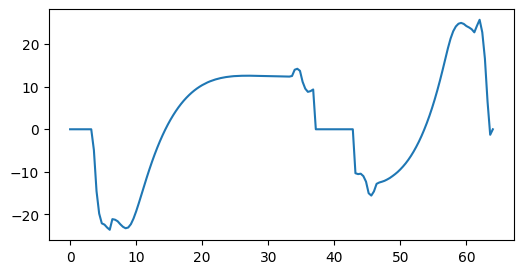

In [22]:
gparams = gropt.GroptParams()

# Optional GPU acceleration
gparams.use_cuda = True
gparams.compile_kernels = True
gparams.compile_mode = "default"
gparams.compile_backend = "eager"
gparams.diff_init()

gparams.add_gmax(.03)
gparams.add_smax(100)
gparams.add_moment(0,0.0)
gparams.add_moment(1,0.0)
# gparams.add_moment(2,0.0)
gparams.add_bvalue(50,1)

start_t = timer()
result = gropt.solve(gparams, max_iter=50000)
out = result.X
stop_t = timer()

print(f'Converged: {result.converged}   Solve time: {1000*(stop_t-start_t):.1f} ms')

plt.figure(figsize=(6,3))
tt_ms = np.arange(out.size(dim=0))*gparams.dt*1e3
plt.plot(tt_ms, out.cpu()*1000)
plt.show()